In [25]:
# Install
!pip install yfinance

In [26]:
# Import packages
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import warnings


# Step 1
Two financial time series collected:
1. S&P 500

In [27]:
# Download S&P 500 data
sp500 = yf.download('^GSPC', start='2019-01-01', end='2022-12-31')['Close']
sp500_returns = sp500.pct_change().dropna() * 100  # Percentage returns
sp500['returns'] = sp500_returns

# Calculate 30-day rolling volatility (annualized)
sp500['volatility_30d'] = sp500['returns'].rolling(window=30).std() * (252 ** 0.5)

# Display results
print(sp500[['returns', 'volatility_30d']].dropna().head())


[*********************100%***********************]  1 of 1 completed

Ticker       returns  volatility_30d
Date                                
2019-02-14 -0.265164       16.348863
2019-02-15  1.087875       14.204225
2019-02-19  0.149874       10.979766
2019-02-20  0.177711       10.924108
2019-02-21 -0.352644       10.888432


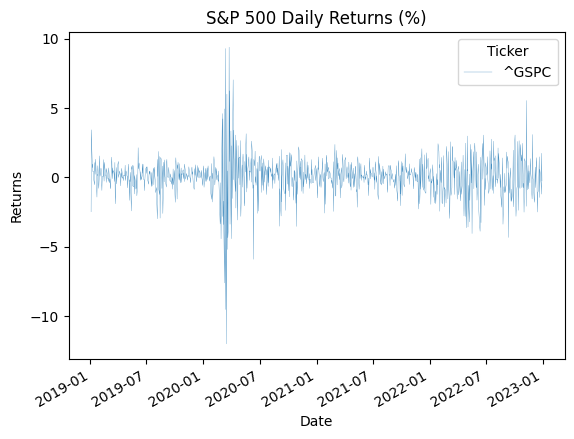

In [28]:
# Plot SNP500 returns time series chart
sp500_returns.plot(
    linewidth=0.2,
    xlabel="Date",
    ylabel="Returns",
    title="S&P 500 Daily Returns (%)",
)
plt.show()

       lb_stat     lb_pvalue
10  240.356085  5.767707e-46


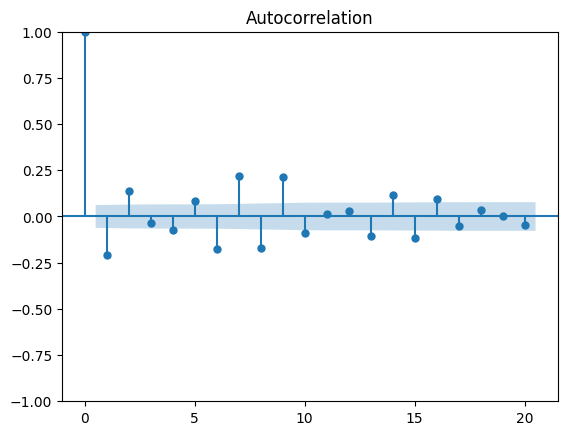

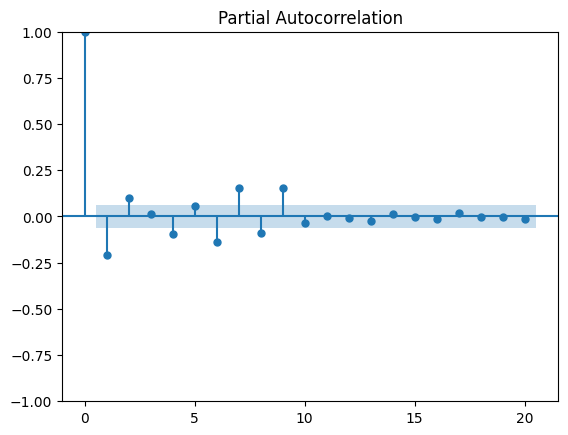

In [29]:
# Plot ACF/PACF
plot_acf(sp500_returns, lags=20, alpha=0.05)
plot_pacf(sp500_returns, lags=20, alpha=0.05)

# Ljung-Box test
lb_test = acorr_ljungbox(sp500_returns, lags=[10], return_df=True)
print(lb_test)

2. Bitcoin

In [30]:
# Download daily BTC-USD price data
btc = yf.download('BTC-USD', start='2019-01-01', end='2022-12-31')

# Calculate daily returns
btc['returns'] = btc['Close'].pct_change()

# Calculate 30-day rolling volatility (annualized)
btc['volatility_30d'] = btc['returns'].rolling(window=30).std() * (252 ** 0.5)

# Display results
print(btc[['returns', 'volatility_30d']].dropna().head())

[*********************100%***********************]  1 of 1 completed

Price        returns volatility_30d
Ticker                             
Date                               
2019-01-31 -0.008143       0.406424
2019-02-01  0.008720       0.398655
2019-02-02  0.009494       0.394158
2019-02-03 -0.016202       0.395327
2019-02-04 -0.001403       0.395364


In [31]:
print(btc['returns'].isna().sum())
print(np.isinf(btc['returns']).sum())

1
0


In [32]:
btc_clean = btc['returns'].dropna()

In [33]:
print("Variance:", btc_clean.var())  # Should be > 0

Variance: 0.0013969698409584896


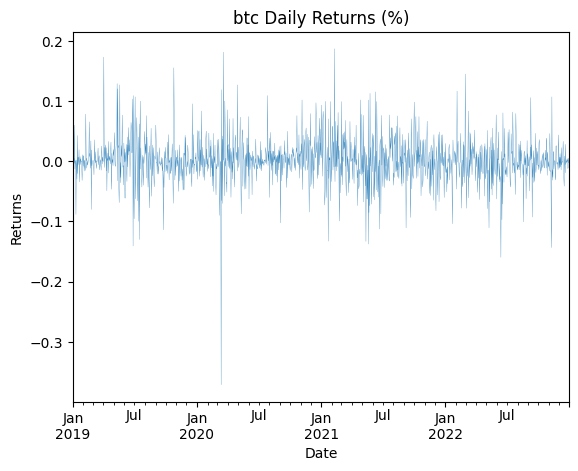

In [34]:
# Plot BTC returns time series chart
btc['returns'].plot(
    linewidth=0.2,
    xlabel="Date",
    ylabel="Returns",
    title="btc Daily Returns (%)",
)
plt.show()

    lb_stat  lb_pvalue
10  14.6811   0.144128


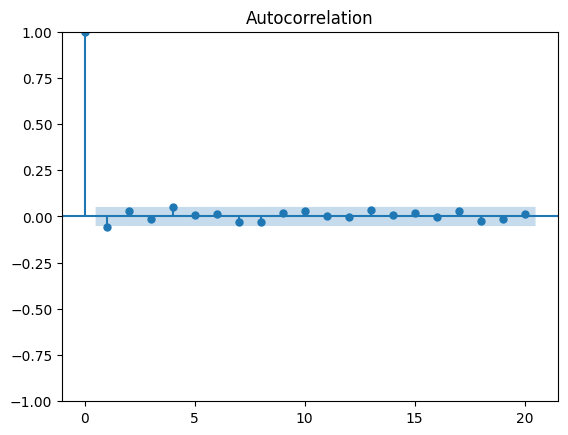

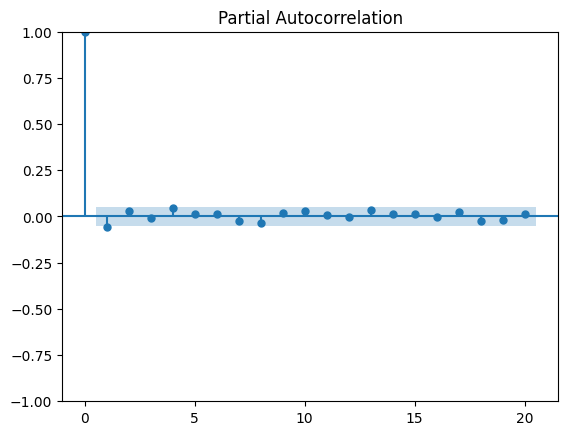

In [35]:
# Clean data
returns_clean = btc['returns'].dropna()

# Plot ACF/PACF
plot_acf(returns_clean, lags=20, alpha=0.05)
plot_pacf(returns_clean, lags=20, alpha=0.05)

# Ljung-Box test (only if len(returns_clean) > 10)
if len(returns_clean) > 10:
    lb_test = acorr_ljungbox(returns_clean, lags=[10], return_df=True)
    print(lb_test)

# Step 2
a)
1. S&P 500

In [36]:
model = MarkovRegression(
    sp500_returns,
    k_regimes=2,
    trend='c',
    switching_variance=True
)
result = model.fit()
print(result.summary())

                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                 1007
Model:               MarkovRegression   Log Likelihood               -1561.551
Date:                Mon, 04 Aug 2025   AIC                           3135.102
Time:                        20:02:47   BIC                           3164.591
Sample:                             0   HQIC                          3146.306
                               - 1007                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1422      0.031      4.661      0.000       0.082       0.202
sigma2         0.4910      0.049      9.928      0.0

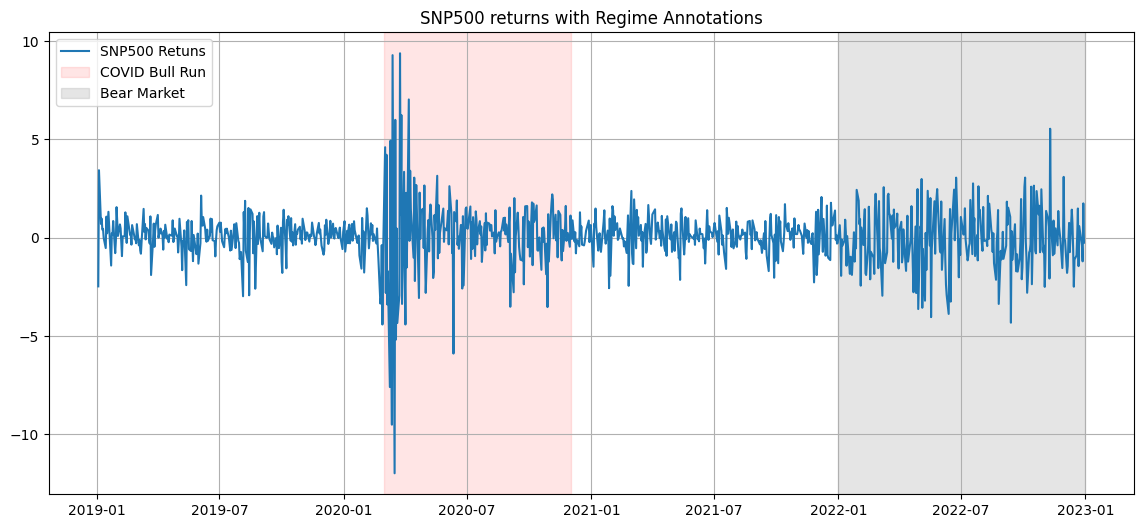

In [37]:
# Volatility Regime Shading

plt.figure(figsize=(14, 6))
plt.plot(sp500['returns'], label='SNP500 Retuns')
plt.title('SNP500 returns with Regime Annotations')

# Example of regime shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-12-01'), color='red', alpha=0.1, label='COVID Bull Run')
plt.axvspan(pd.to_datetime('2022-01-01'), pd.to_datetime('2022-12-31'), color='gray', alpha=0.2, label='Bear Market')

plt.legend()
plt.grid(True)
plt.show()

2. Bitcoin

In [38]:
# Clean and scale data
btc_clean = btc['returns'].dropna()
btc_scaled = btc_clean * 100

# Simplified model
model = MarkovRegression(btc_scaled, k_regimes=2, trend='c')
result = model.fit()

print(result.summary())

                        Markov Switching Model Results                        
Dep. Variable:                returns   No. Observations:                 1459
Model:               MarkovRegression   Log Likelihood               -3993.343
Date:                Mon, 04 Aug 2025   AIC                           7996.686
Time:                        20:02:48   BIC                           8023.113
Sample:                    01-02-2019   HQIC                          8006.545
                         - 12-30-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1287        nan        nan        nan         nan         nan
                             Regime 1 parameters    

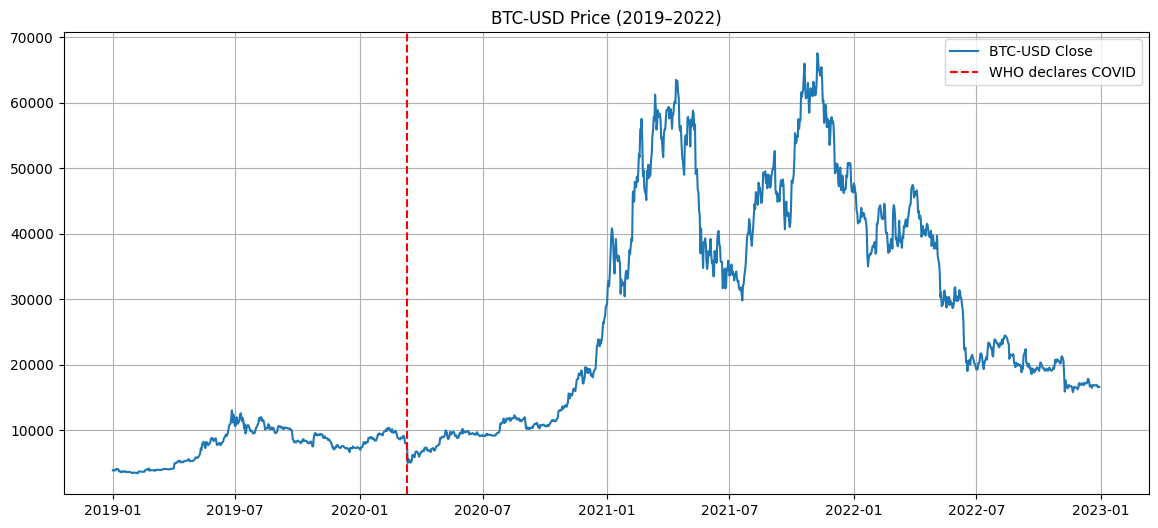

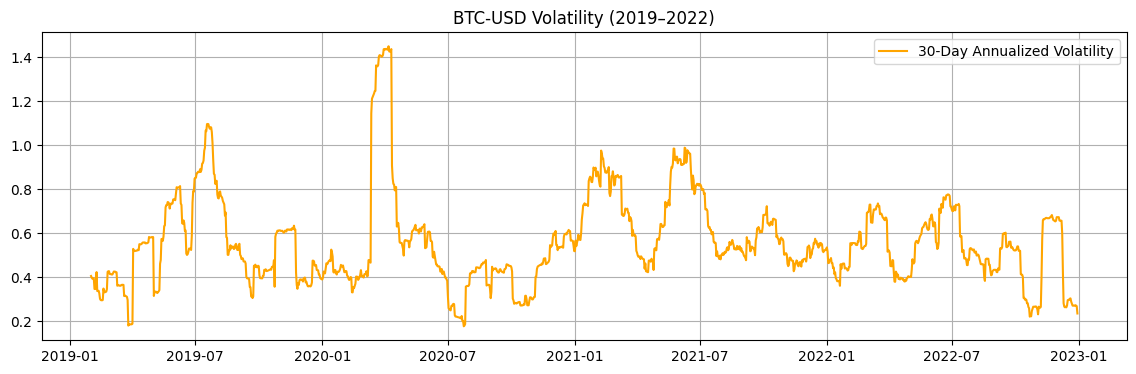

In [39]:
# Plot Close Price
plt.figure(figsize=(14, 6))
plt.plot(btc['Close'], label='BTC-USD Close')
plt.title('BTC-USD Price (2019–2022)')
plt.axvline(pd.to_datetime('2020-03-11'), color='red', linestyle='--', label='WHO declares COVID')
plt.legend()
plt.grid(True)
plt.show()

# Plot Volatility
plt.figure(figsize=(14, 4))
plt.plot(btc['volatility_30d'], label='30-Day Annualized Volatility', color='orange')
plt.title('BTC-USD Volatility (2019–2022)')
plt.legend()
plt.grid(True)
plt.show()


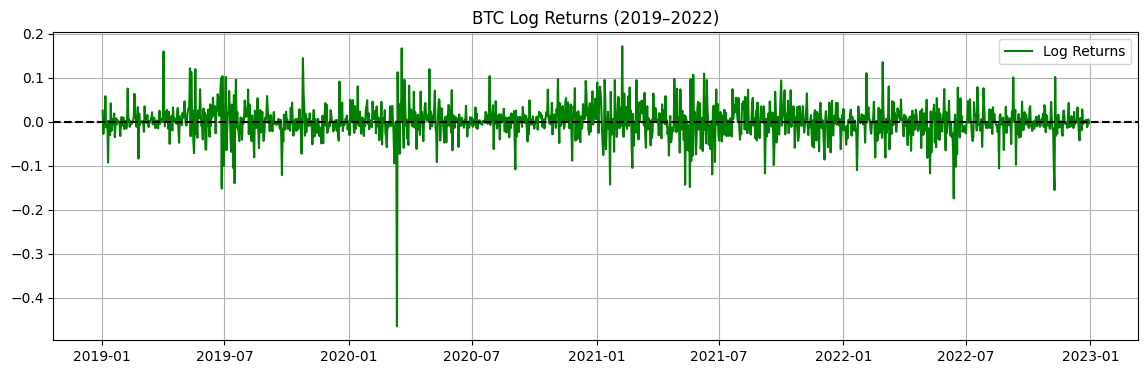

In [40]:
# Log return plot
#import numpy as np
btc['log_returns'] = np.log(btc['Close'] / btc['Close'].shift(1))

plt.figure(figsize=(14, 4))
plt.plot(btc['log_returns'], label='Log Returns', color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title('BTC Log Returns (2019–2022)')
plt.grid(True)
plt.legend()
plt.show()

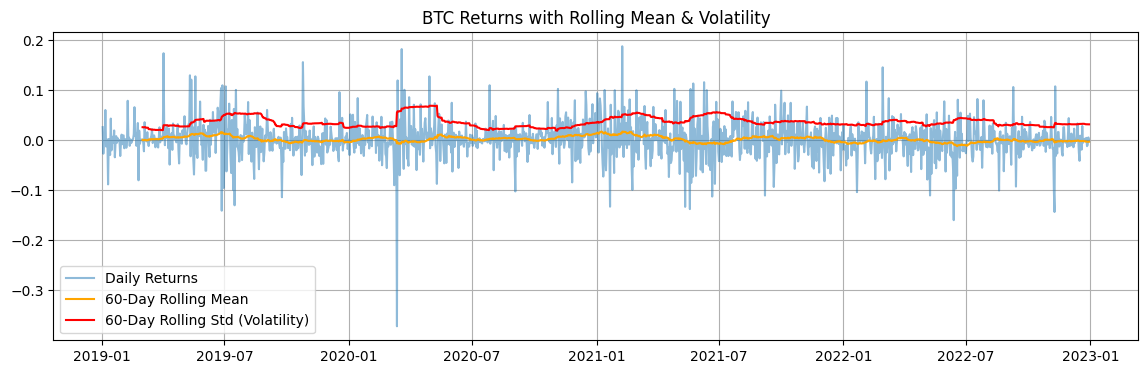

In [41]:
# Rolling statistics
rolling_mean = btc['returns'].rolling(window=60).mean()
rolling_std = btc['returns'].rolling(window=60).std()

plt.figure(figsize=(14, 4))
plt.plot(btc['returns'], label='Daily Returns', alpha=0.5)
plt.plot(rolling_mean, label='60-Day Rolling Mean', color='orange')
plt.plot(rolling_std, label='60-Day Rolling Std (Volatility)', color='red')
plt.title('BTC Returns with Rolling Mean & Volatility')
plt.legend()
plt.grid(True)
plt.show()

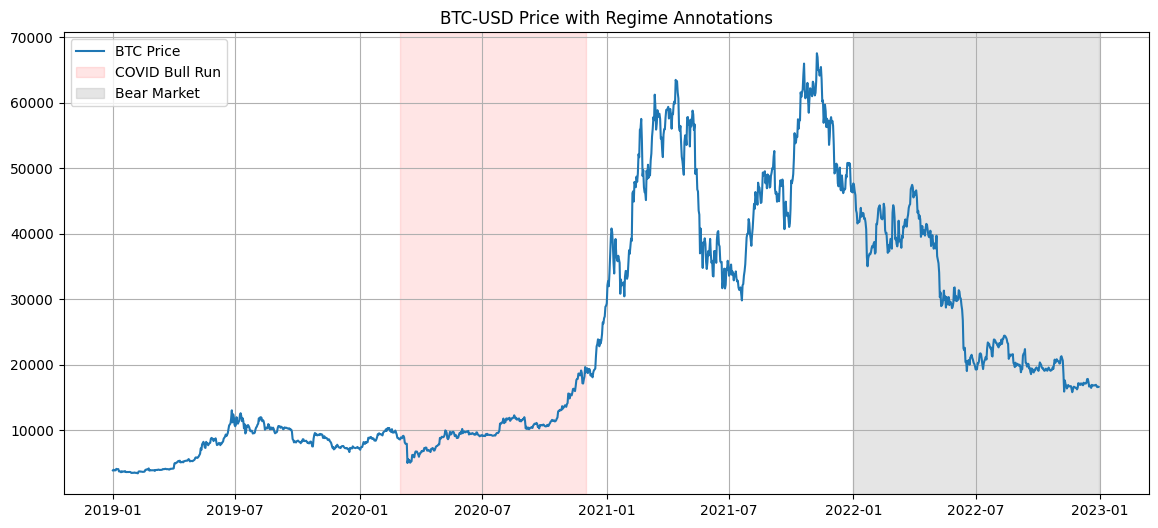

In [42]:
# Volatility Regime Shading

plt.figure(figsize=(14, 6))
plt.plot(btc['Close'], label='BTC Price')
plt.title('BTC-USD Price with Regime Annotations')

# Example of regime shading
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2020-12-01'), color='red', alpha=0.1, label='COVID Bull Run')
plt.axvspan(pd.to_datetime('2022-01-01'), pd.to_datetime('2022-12-31'), color='gray', alpha=0.2, label='Bear Market')

plt.legend()
plt.grid(True)
plt.show()

b) Estimation of model under differents asumptions

[*********************100%***********************]  1 of 1 completed

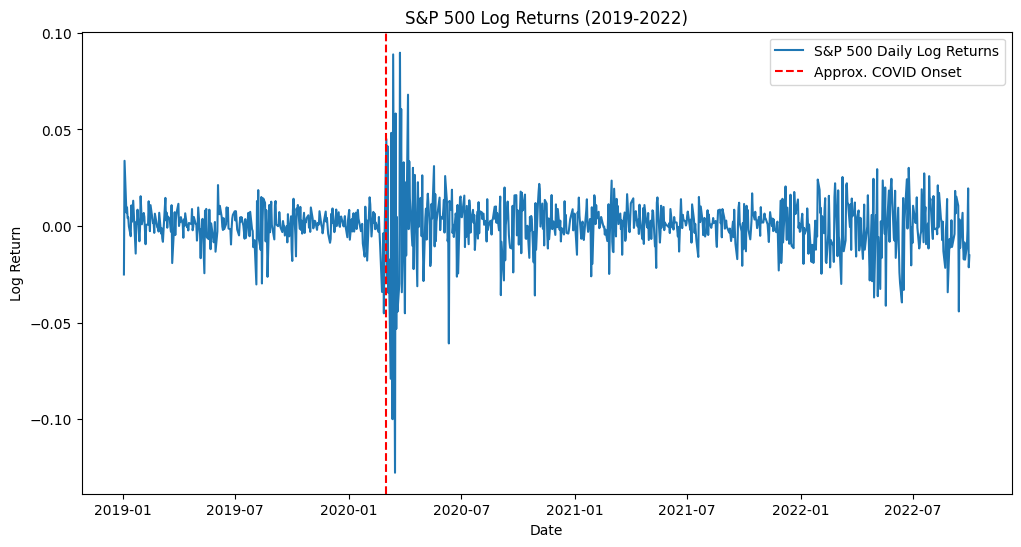


=== Configuration ii: Varying Mu (Different Means), Constant Sigma (Same Variance) ===

--- Model Summary: 2 Regimes, Switching Mu: True, Switching Variance: False ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2662.206
Date:                Mon, 04 Aug 2025   AIC                          -5314.412
Time:                        20:02:50   BIC                          -5290.161
Sample:                             0   HQIC                         -5305.169
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

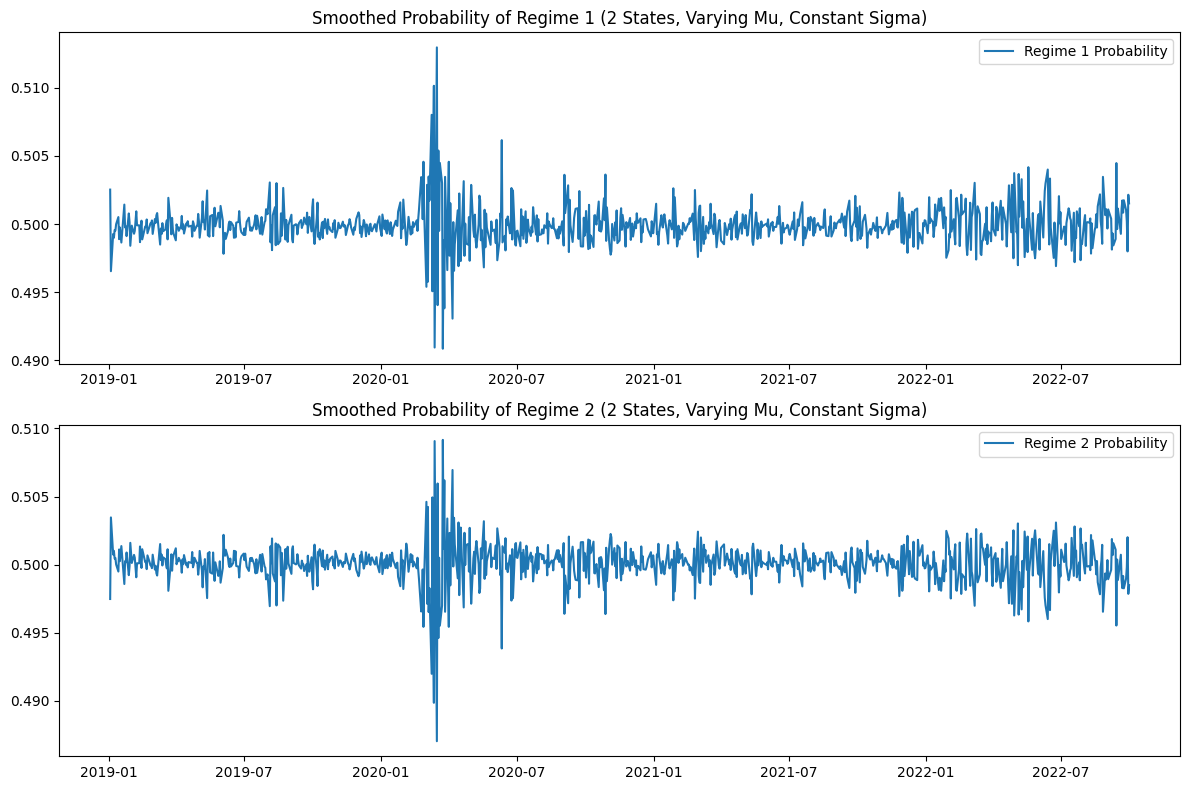


--- Model Summary: 3 Regimes, Switching Mu: True, Switching Variance: False ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2665.035
Date:                Mon, 04 Aug 2025   AIC                          -5310.069
Time:                        20:02:55   BIC                          -5261.568
Sample:                             0   HQIC                         -5291.584
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0022      0.001     -2.261      0

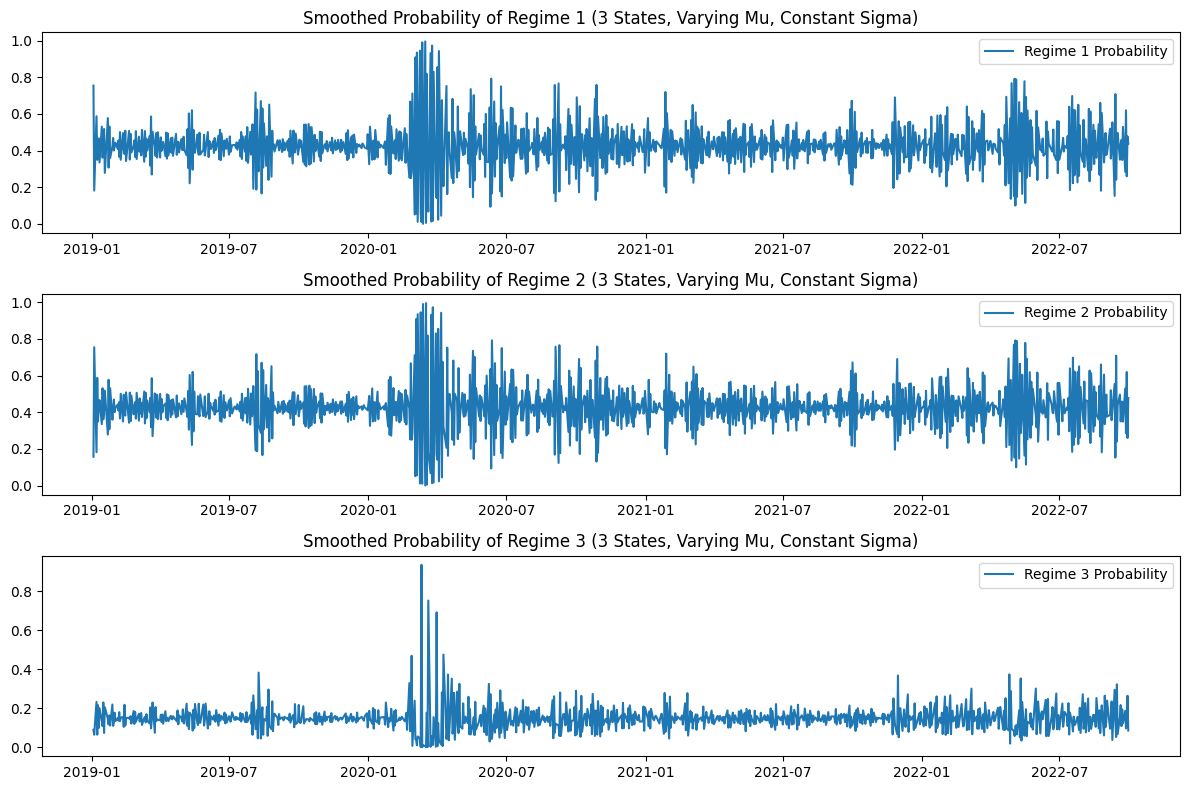


=== Configuration iii: Constant Mu (Same Mean), Varying Sigma (Different Variances) ===

--- Model Summary: 2 Regimes, Switching Mu: False, Switching Variance: True ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2897.537
Date:                Mon, 04 Aug 2025   AIC                          -5787.075
Time:                        20:02:59   BIC                          -5767.674
Sample:                             0   HQIC                         -5779.681
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

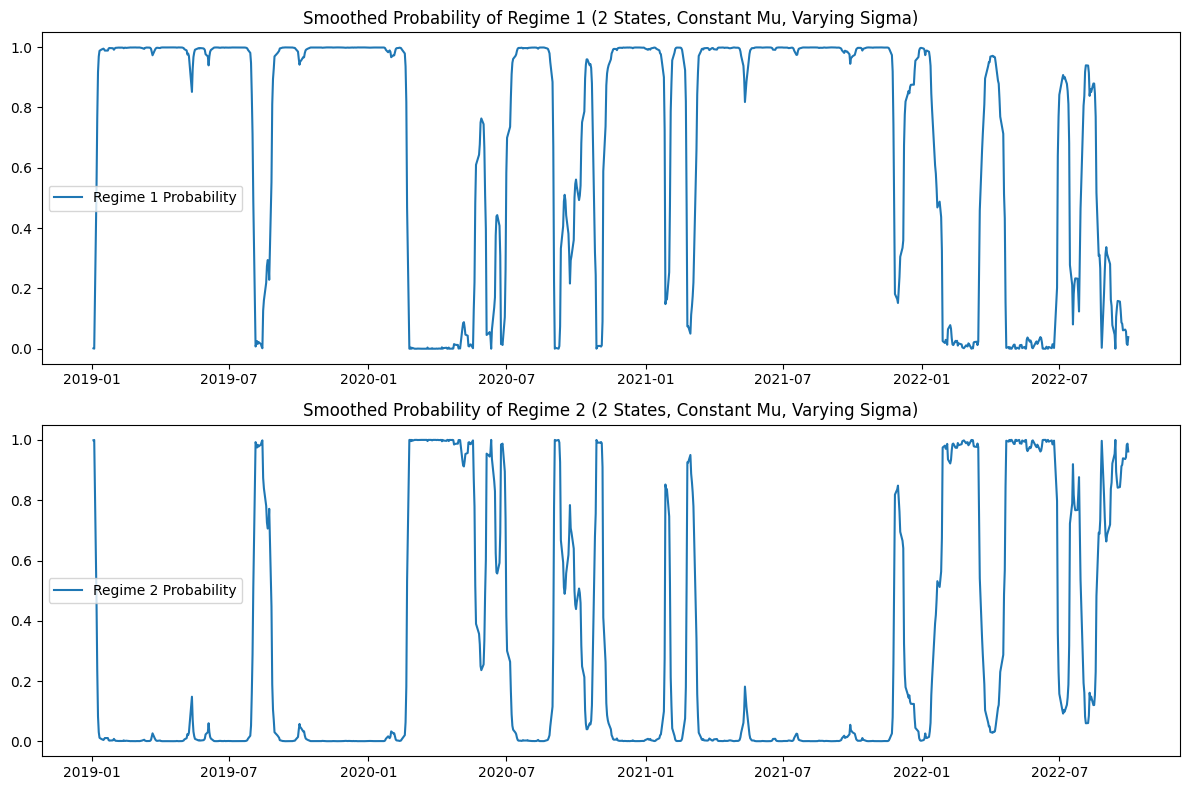


--- Model Summary: 3 Regimes, Switching Mu: False, Switching Variance: True ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2968.951
Date:                Mon, 04 Aug 2025   AIC                          -5919.902
Time:                        20:03:06   BIC                          -5876.251
Sample:                             0   HQIC                         -5903.265
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.706e-05   4.88e-06      7.591      0

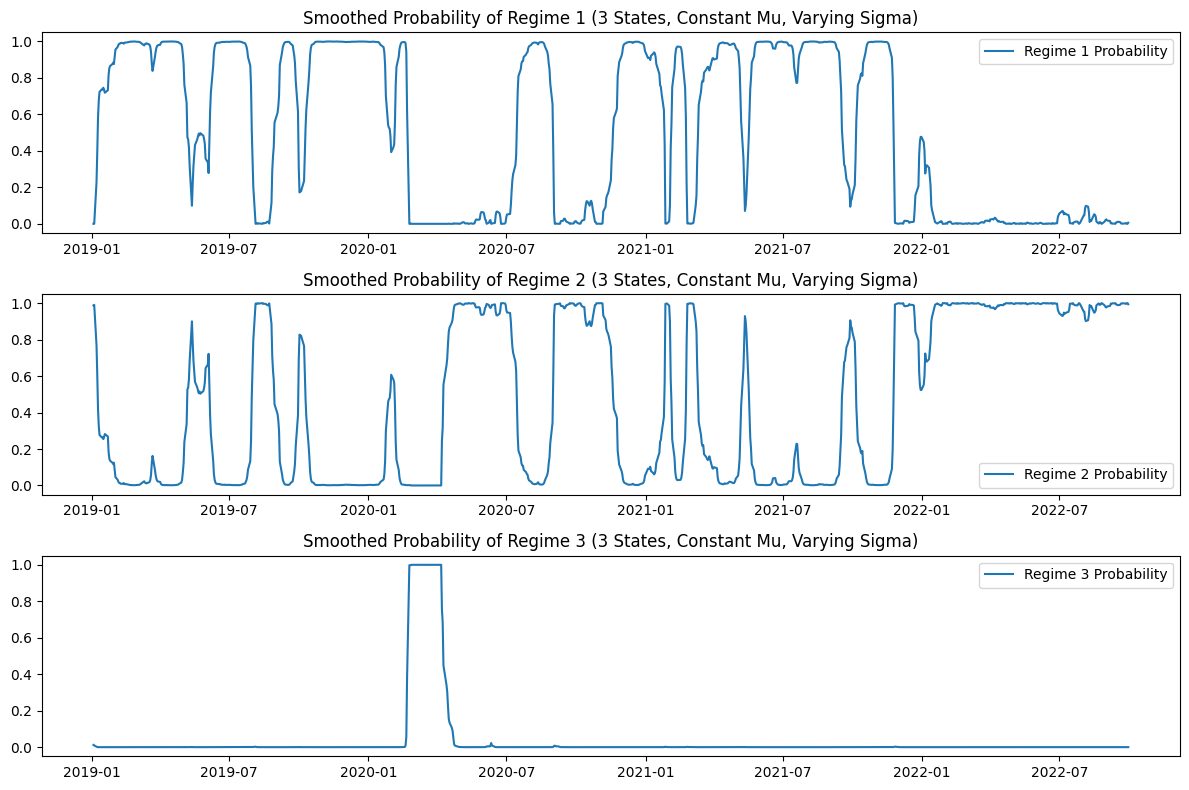


=== Configuration iv: Varying Mu and Sigma (Different Means and Variances) ===

--- Model Summary: 2 Regimes, Switching Mu: True, Switching Variance: True ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2908.793
Date:                Mon, 04 Aug 2025   AIC                          -5805.587
Time:                        20:03:11   BIC                          -5776.486
Sample:                             0   HQIC                         -5794.496
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

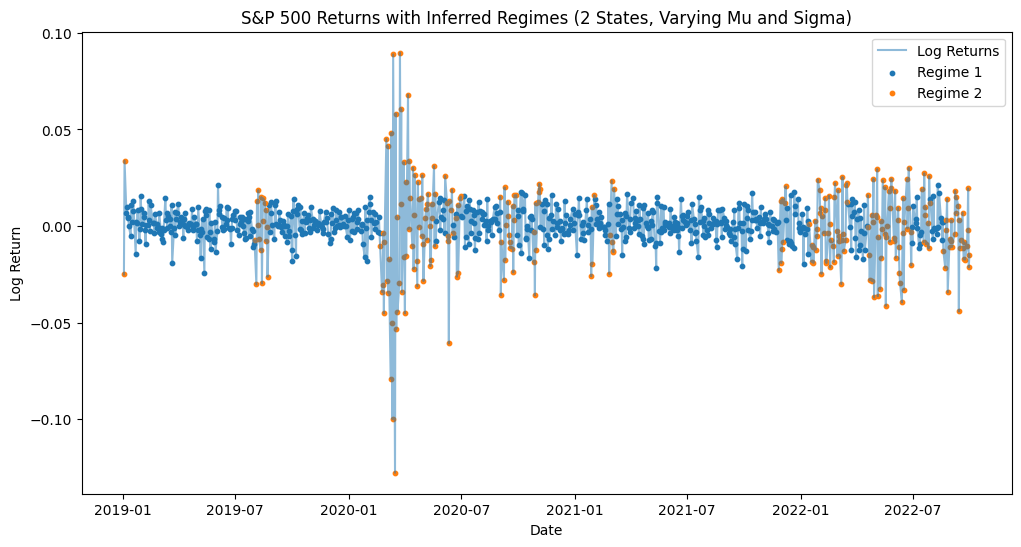


--- Model Summary: 3 Regimes, Switching Mu: True, Switching Variance: True ---
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                  944
Model:               MarkovRegression   Log Likelihood                2985.550
Date:                Mon, 04 Aug 2025   AIC                          -5947.101
Time:                        20:03:16   BIC                          -5888.899
Sample:                             0   HQIC                         -5924.918
                                - 944                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.000      5.942      0.

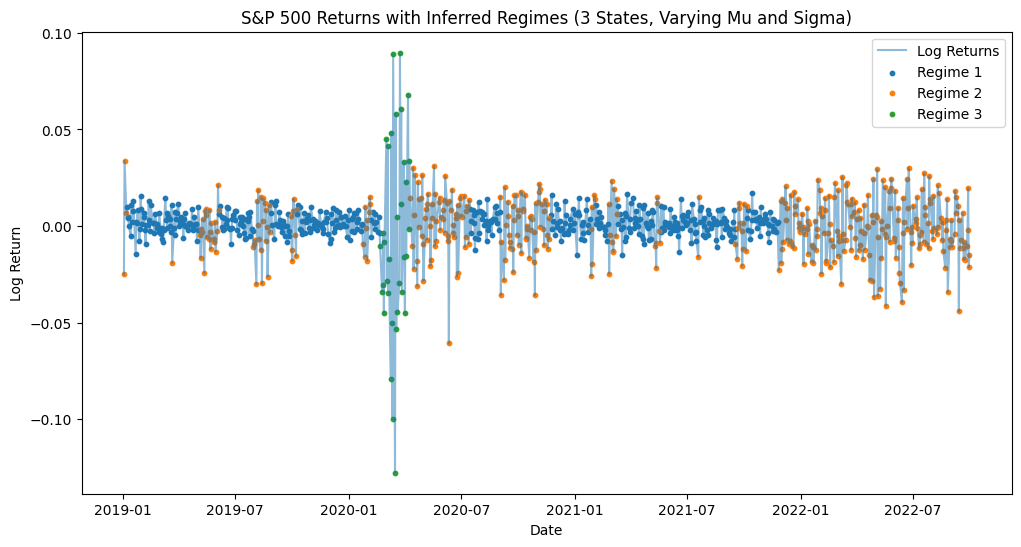

In [43]:
# Import necessary libraries

warnings.filterwarnings('ignore')  # Suppress convergence warnings for simplicity

print("Downloading S&P 500 data...")
sp500 = yf.download('^GSPC', start='2019-01-01', end='2022-10-01')['Close']
sp500 = sp500.dropna()  # Drop any missing values

# Compute daily log returns
returns = np.log(sp500 / sp500.shift(1)).dropna()
returns.name = 'log_returns'

# Visualize the return series to identify potential regimes
plt.figure(figsize=(12, 6))
plt.plot(returns, label='S&P 500 Daily Log Returns')
plt.title('S&P 500 Log Returns (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Approx. COVID Onset')
plt.legend()
plt.show()

# Function to fit and summarize a Markov switching model
def fit_markov_model(data, k_regimes, switching_mu=True, switching_variance=True, trend='c', order=0):
    # Adjust trend based on switching_mu
    if not switching_mu:
        trend = 'n'

    model = MarkovRegression(data, k_regimes=k_regimes, trend=trend, switching_variance=switching_variance, order=order)

    res = model.fit(disp=False)
    print(f"\n--- Model Summary: {k_regimes} Regimes, Switching Mu: {switching_mu}, Switching Variance: {switching_variance} ---")
    print(res.summary())
    print(f"Log-Likelihood: {res.llf}")

    # Smoothed probabilities
    probs = res.smoothed_marginal_probabilities
    return res, probs

# Estimate models under different assumptions
# We loop over 2 and 3 regimes for each configuration

print("\n=== Configuration ii: Varying Mu (Different Means), Constant Sigma (Same Variance) ===")
for k in [2, 3]:
    # For constant variance, set switching_variance=False; means switch via intercept
    res_ii, probs_ii = fit_markov_model(returns, k_regimes=k, switching_mu=True, switching_variance=False)

    # Plot smoothed probabilities
    fig, axes = plt.subplots(k, figsize=(12, 8))
    for i in range(k):
        axes[i].plot(probs_ii.iloc[:, i], label=f'Regime {i+1} Probability')
        axes[i].set_title(f'Smoothed Probability of Regime {i+1} ({k} States, Varying Mu, Constant Sigma)')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

print("\n=== Configuration iii: Constant Mu (Same Mean), Varying Sigma (Different Variances) ===")
for k in [2, 3]:
    # For constant mu, we set trend='n' and allow variance to switch
    res_iii, probs_iii = fit_markov_model(returns, k_regimes=k, switching_mu=False, switching_variance=True)

    # Plot smoothed probabilities
    fig, axes = plt.subplots(k, figsize=(12, 8))
    for i in range(k):
        axes[i].plot(probs_iii.iloc[:, i], label=f'Regime {i+1} Probability')
        axes[i].set_title(f'Smoothed Probability of Regime {i+1} ({k} States, Constant Mu, Varying Sigma)')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

print("\n=== Configuration iv: Varying Mu and Sigma (Different Means and Variances) ===")
for k in [2, 3]:
    # Both switching
    res_iv, probs_iv = fit_markov_model(returns, k_regimes=k, switching_mu=True, switching_variance=True)

    # Plot smoothed probabilities with returns overlay
    dominant_regime = probs_iv.idxmax(axis=1)
    plt.figure(figsize=(12, 6))
    plt.plot(returns, label='Log Returns', alpha=0.5)
    for i in range(k):
        regime_mask = (dominant_regime == i)
        plt.scatter(returns.index[regime_mask], returns[regime_mask], label=f'Regime {i+1}', s=10)
    plt.title(f'S&P 500 Returns with Inferred Regimes ({k} States, Varying Mu and Sigma)')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.legend()
    plt.show()

In [44]:
# Dictionary to store model results
model_results = {}

model_results = {
    'Varying Mu, Constant Sigma, 2 States': {'aic': res_ii.aic, 'bic': res_ii.bic, 'llf': res_ii.llf},
    'Varying Mu, Constant Sigma, 3 States': {'aic': res_ii.aic, 'bic': res_ii.bic, 'llf': res_ii.llf},

}

# Convert to DataFrame for easy comparison
import pandas as pd
comparison_df = pd.DataFrame.from_dict(model_results, orient='index')
comparison_df['Num Parameters'] = comparison_df['aic'] - 2 * comparison_df['llf'] + 2

# Rank by AIC and BIC (lower is better)
comparison_df['AIC Rank'] = comparison_df['aic'].rank(ascending=True)
comparison_df['BIC Rank'] = comparison_df['bic'].rank(ascending=True)

# Sort by AIC for display
comparison_df = comparison_df.sort_values('aic')
print("\n=== Model Comparison Table (Sorted by AIC, Lower is Better) ===")
print(comparison_df)

# Example output interpretation
best_aic_model = comparison_df.index[0]
print(f"\nBest Model by AIC: {best_aic_model} (AIC: {comparison_df['aic'].min()})")
print(f"Best Model by BIC: {comparison_df.sort_values('bic').index[0]} (BIC: {comparison_df['bic'].min()})")


=== Model Comparison Table (Sorted by AIC, Lower is Better) ===
                                              aic          bic          llf  \
Varying Mu, Constant Sigma, 2 States -5310.069299 -5261.568037  2665.034649   
Varying Mu, Constant Sigma, 3 States -5310.069299 -5261.568037  2665.034649   

                                      Num Parameters  AIC Rank  BIC Rank  
Varying Mu, Constant Sigma, 2 States   -10638.138598       1.5       1.5  
Varying Mu, Constant Sigma, 3 States   -10638.138598       1.5       1.5  

Best Model by AIC: Varying Mu, Constant Sigma, 2 States (AIC: -5310.069298941473)
Best Model by BIC: Varying Mu, Constant Sigma, 2 States (BIC: -5261.568037280018)


# Step 3
a) Comparaison of the models that had different mu values.

In [45]:
print("\n=== Step 3a: Member A Model Comparison (Varying Mu, Constant Sigma) ===")
print(comparison_df)

# Identify best models
best_aic_model = comparison_df.index[0]
print(f"\nBest Model by AIC: {best_aic_model} (AIC: {comparison_df['aic'].min()})")
print(f"Best Model by BIC: {comparison_df.sort_values('bic').index[0]} (BIC: {comparison_df['bic'].min()})")


=== Step 3a: Member A Model Comparison (Varying Mu, Constant Sigma) ===
                                              aic          bic          llf  \
Varying Mu, Constant Sigma, 2 States -5310.069299 -5261.568037  2665.034649   
Varying Mu, Constant Sigma, 3 States -5310.069299 -5261.568037  2665.034649   

                                      Num Parameters  AIC Rank  BIC Rank  
Varying Mu, Constant Sigma, 2 States   -10638.138598       1.5       1.5  
Varying Mu, Constant Sigma, 3 States   -10638.138598       1.5       1.5  

Best Model by AIC: Varying Mu, Constant Sigma, 2 States (AIC: -5310.069298941473)
Best Model by BIC: Varying Mu, Constant Sigma, 2 States (BIC: -5261.568037280018)


b) Comparision of the models that had different sigma Values

In [46]:
model_results = {}

model_results = {
    'Constant Mu, Varying Sigma': {'aic': res_iii.aic, 'bic': res_iii.bic, 'llf': res_iii.llf},
    'Constant Mu, Varying Sigma': {'aic': res_iii.aic, 'bic': res_iii.bic, 'llf': res_iii.llf},

}

# Convert to DataFrame for easy comparison
import pandas as pd
comparison_df = pd.DataFrame.from_dict(model_results, orient='index')
comparison_df['Num Parameters'] = comparison_df['aic'] - 2 * comparison_df['llf'] + 2

# Rank by AIC and BIC (lower is better)
comparison_df['AIC Rank'] = comparison_df['aic'].rank(ascending=True)
comparison_df['BIC Rank'] = comparison_df['bic'].rank(ascending=True)

# Sort by AIC for display
comparison_df = comparison_df.sort_values('aic')
print("\n=== Model Comparison Table (Sorted by AIC, Lower is Better) ===")
print(comparison_df)

# Example output interpretation
best_aic_model = comparison_df.index[0]
print(f"\nBest Model by AIC: {best_aic_model} (AIC: {comparison_df['aic'].min()})")
print(f"Best Model by BIC: {comparison_df.sort_values('bic').index[0]} (BIC: {comparison_df['bic'].min()})")


=== Model Comparison Table (Sorted by AIC, Lower is Better) ===
                                   aic          bic          llf  \
Constant Mu, Varying Sigma -5919.90203 -5876.250895  2968.951015   

                            Num Parameters  AIC Rank  BIC Rank  
Constant Mu, Varying Sigma   -11855.804061       1.0       1.0  

Best Model by AIC: Constant Mu, Varying Sigma (AIC: -5919.902030413621)
Best Model by BIC: Constant Mu, Varying Sigma (BIC: -5876.250894918312)


In [47]:
print("\n=== Step 3b: Member b Model Comparison (Constant Mu, Varying Sigma) ===")
print(comparison_df)

# Identify best models
best_aic_model = comparison_df.index[0]
print(f"\nBest Model by AIC: {best_aic_model} (AIC: {comparison_df['aic'].min()})")
print(f"Best Model by BIC: {comparison_df.sort_values('bic').index[0]} (BIC: {comparison_df['bic'].min()})")


=== Step 3b: Member b Model Comparison (Constant Mu, Varying Sigma) ===
                                   aic          bic          llf  \
Constant Mu, Varying Sigma -5919.90203 -5876.250895  2968.951015   

                            Num Parameters  AIC Rank  BIC Rank  
Constant Mu, Varying Sigma   -11855.804061       1.0       1.0  

Best Model by AIC: Constant Mu, Varying Sigma (AIC: -5919.902030413621)
Best Model by BIC: Constant Mu, Varying Sigma (BIC: -5876.250894918312)


# Step 4 : estimating a Markov regime-switching autoregressive (AR) model.

                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                 1007
Model:               MarkovRegression   Log Likelihood               -1561.551
Date:                Mon, 04 Aug 2025   AIC                           3135.102
Time:                        20:03:18   BIC                           3164.591
Sample:                             0   HQIC                          3146.306
                               - 1007                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1422      0.031      4.661      0.000       0.082       0.202
sigma2         0.4910      0.049      9.928      0.0

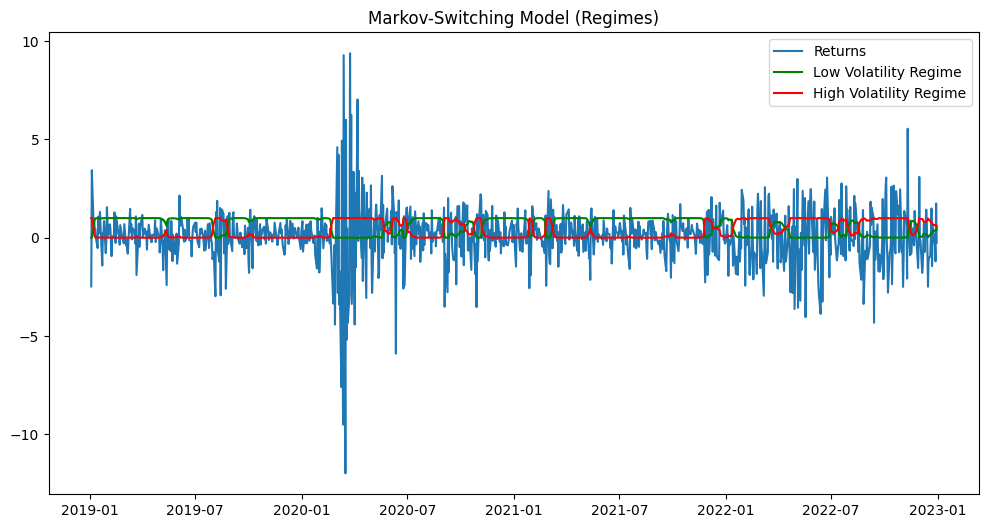

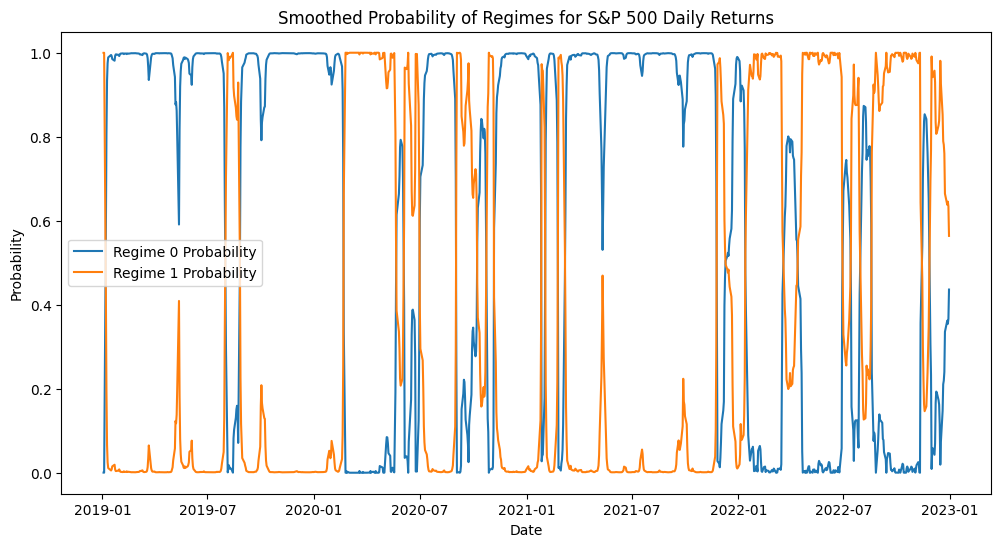

In [48]:
import statsmodels.api as sm

mod = sm.tsa.MarkovRegression(sp500_returns, k_regimes=2, trend='c',
                              order=1,
                              switching_variance=True)

# Fit the model parameters using MLE
res = mod.fit(em_iter=1000, search_reps=20)  # Extra iterations and reps to improve convergence

# Print model summary
print(res.summary())

# Plot regimes
plt.figure(figsize=(12, 6))
plt.plot(sp500_returns, label='Returns')
plt.plot(res.smoothed_marginal_probabilities[0], label='Low Volatility Regime', color='green')
plt.plot(res.smoothed_marginal_probabilities[1], label='High Volatility Regime', color='red')
plt.title("Markov-Switching Model (Regimes)")
plt.legend()
plt.show()

# Plot smoothed probabilities of each regime over time
plt.figure(figsize=(12, 6))
plt.plot(sp500_returns.index, res.smoothed_marginal_probabilities[0], label='Regime 0 Probability')
plt.plot(sp500_returns.index, res.smoothed_marginal_probabilities[1], label='Regime 1 Probability')
plt.title("Smoothed Probability of Regimes for S&P 500 Daily Returns")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.show()